<a href="https://colab.research.google.com/github/Killian091/Machine_Learning/blob/main/Housing_Prices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import tarfile
from six.moves import urllib
DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
HOUSING_PATH = os.path.join("datasets", "housing")
HOUSING_URL = DOWNLOAD_ROOT + "datasets/housing/housing.tgz"
def fetch_housing_data(housing_url=HOUSING_URL, housing_path=HOUSING_PATH):
  if not os.path.isdir(housing_path):
    os.makedirs(housing_path)
  tgz_path = os.path.join(housing_path, "housing.tgz")
  urllib.request.urlretrieve(housing_url, tgz_path)
  housing_tgz = tarfile.open(tgz_path)
  housing_tgz.extractall(path=housing_path)
  housing_tgz.close()

In [2]:
import pandas as pd
fetch_housing_data()
housing_csv_path = os.path.join(HOUSING_PATH, "housing.csv")
housing = pd.read_csv(housing_csv_path)
display(housing.head())

/tmp/ipykernel_430/1758382696.py:13: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tgz.extractall(path=housing_path)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [4]:
housing["ocean_proximity"].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


In [5]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


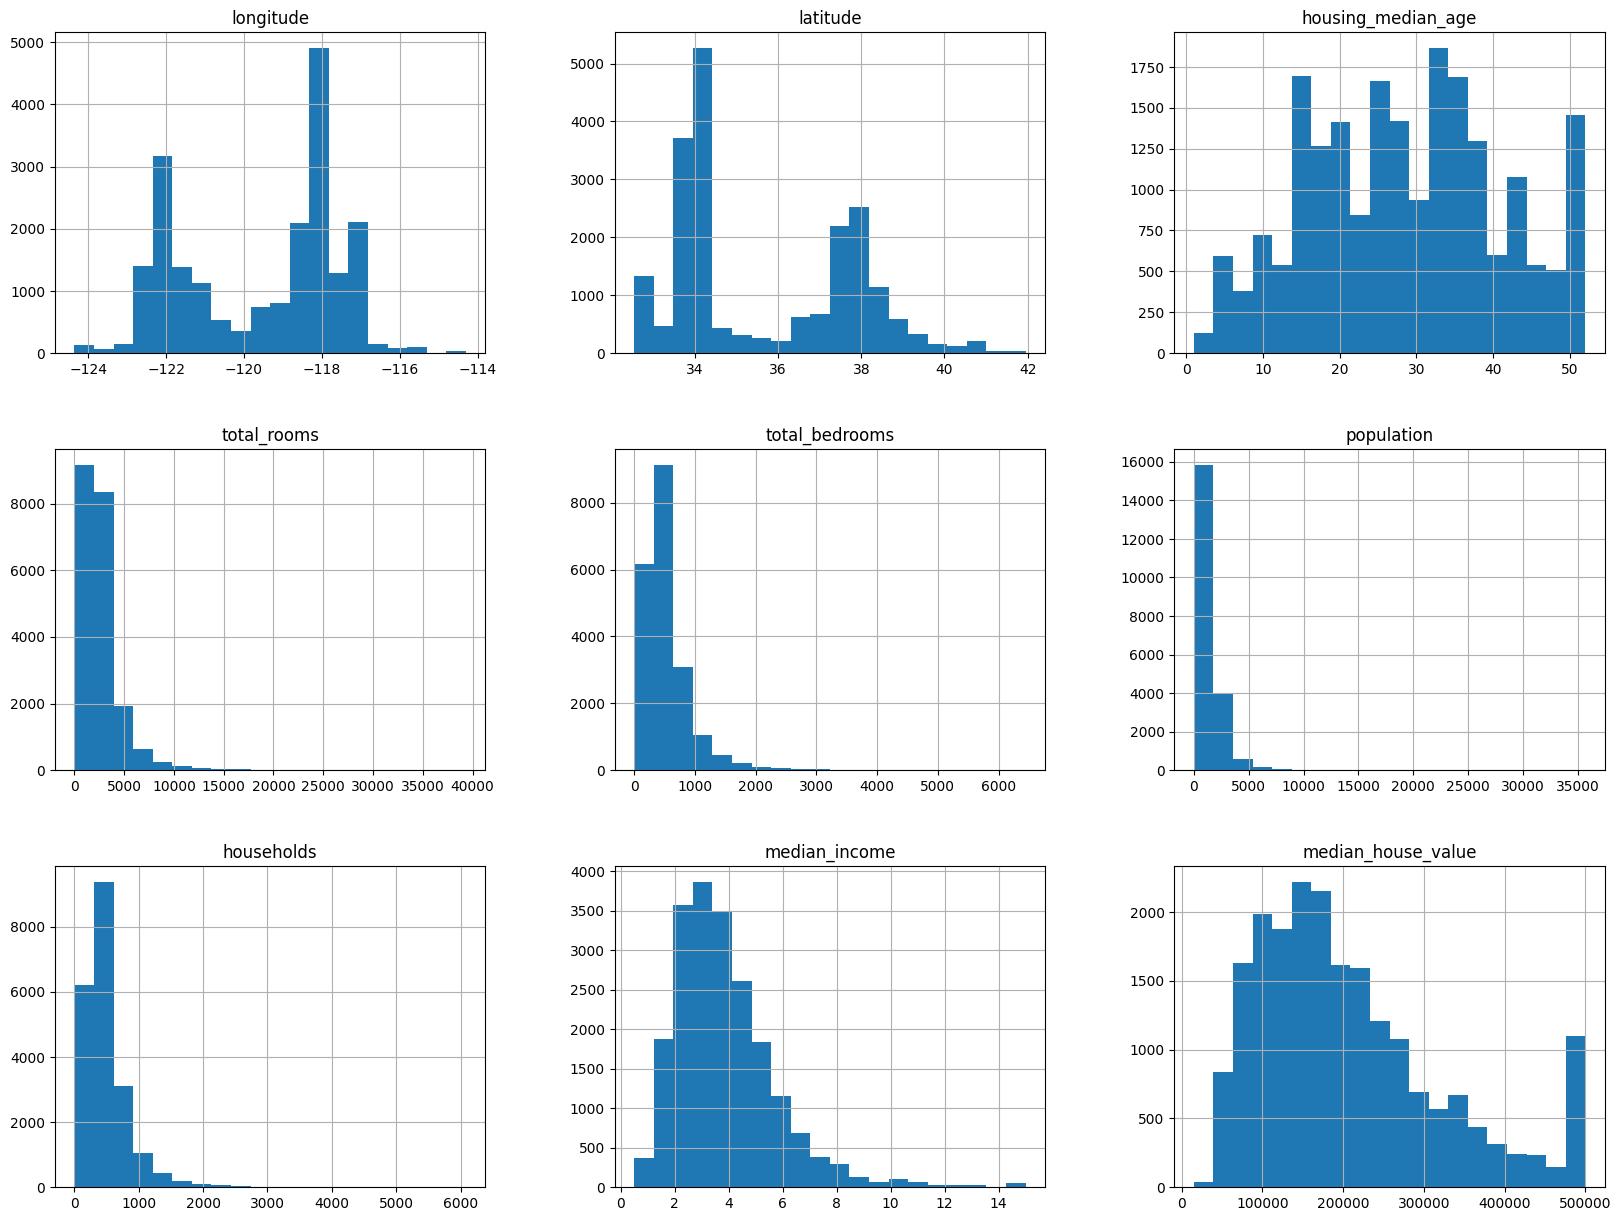

In [6]:
import matplotlib.pyplot as plt
housing.hist(bins=20, figsize=(20,15))
plt.show()

## **Train_Test_Split**

In [7]:
import numpy as np

def split_train_test(data, test_ratio):
  shuffled_indices = np.random.permutation(len(data))
  test_set_size = int(len(data)*test_ratio)
  test_indices = shuffled_indices[: test_set_size]
  train_indices = shuffled_indices[test_set_size :]
  return data.iloc[test_indices], data.iloc[train_indices]

In [8]:
test_set, train_set = split_train_test(housing, 0.2)
len(test_set)

4128

In [9]:
test_set[:10]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
13573,-117.29,34.14,45.0,1598.0,314.0,771.0,319.0,2.5417,82900.0,INLAND
41,-122.26,37.83,51.0,936.0,311.0,517.0,249.0,1.2852,150000.0,NEAR BAY
18032,-121.94,37.24,19.0,1741.0,294.0,632.0,279.0,5.5944,290500.0,<1H OCEAN
2553,-124.18,40.78,37.0,1453.0,293.0,867.0,310.0,2.5536,70200.0,NEAR OCEAN
14728,-117.02,32.80,29.0,1232.0,243.0,665.0,247.0,3.6500,168900.0,<1H OCEAN
11308,-117.93,33.77,36.0,3157.0,582.0,1842.0,561.0,4.5833,190700.0,<1H OCEAN
10886,-117.91,33.71,16.0,3113.0,783.0,1719.0,715.0,3.6505,145700.0,<1H OCEAN
5246,-118.45,34.12,20.0,10722.0,1617.0,3731.0,1511.0,9.7449,500001.0,<1H OCEAN
14309,-117.13,32.71,35.0,614.0,180.0,691.0,164.0,1.6953,81300.0,NEAR OCEAN
1111,-121.60,39.79,18.0,2672.0,533.0,1151.0,532.0,2.5670,102900.0,INLAND


## **Stratified** **Sampling**

<Axes: >

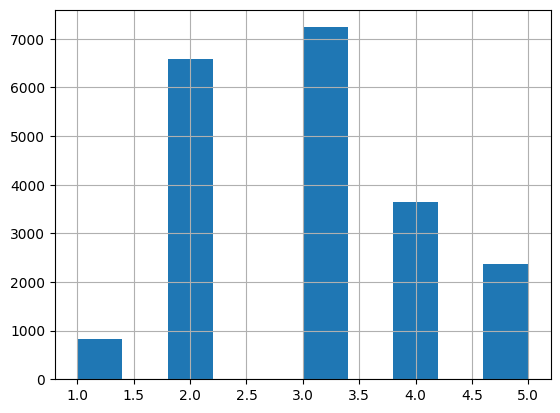

In [10]:
housing["income_categ"] = pd.cut(housing["median_income"], bins=[0,1.5,3,4.5,6., np.inf], labels=[1,2,3,4,5])

housing["income_categ"].hist()

**Train_Test_Split**

In [12]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing, housing["income_categ"]):
  strat_train_set = housing.loc[train_index]
  strat_test_set = housing.loc[test_index]

In [15]:
# Income Category Proportions

strat_test_set["income_categ"].value_counts()/len(strat_test_set)

,count
income_categ,
3,0.350533
2,0.318798
4,0.176357
5,0.114341
1,0.039971


In [16]:
# Remove the Income_Categ column from the housing data

for set_ in (strat_train_set, strat_test_set):
  set_.drop("income_categ", axis=1, inplace=True)

In [ ]:
strat_train_set.head()

In [18]:
housing = strat_train_set.copy()

## **Visualizing** **Geographical** **Data**

<Axes: xlabel='longitude', ylabel='latitude'>

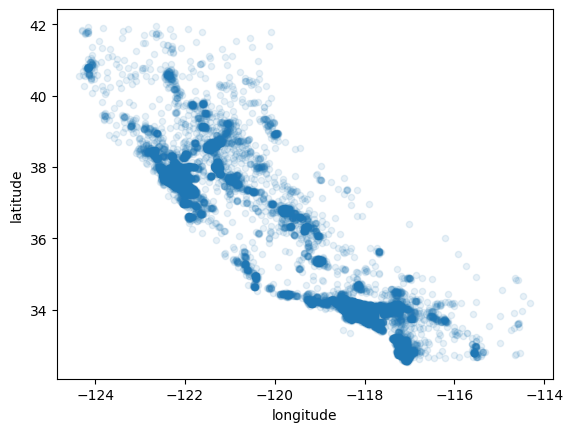

In [20]:
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.1)

In [22]:
housing.head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,72100.0,INLAND
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,279600.0,NEAR OCEAN
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,82700.0,INLAND
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,112500.0,NEAR OCEAN
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,238300.0,<1H OCEAN
1481,-122.04,37.96,28.0,1207.0,252.0,724.0,252.0,3.6964,165700.0,NEAR BAY
18125,-122.03,37.33,23.0,4221.0,671.0,1782.0,641.0,7.4863,412300.0,<1H OCEAN
5830,-118.31,34.20,36.0,1692.0,263.0,778.0,278.0,5.0865,349600.0,<1H OCEAN
17989,-121.95,37.27,17.0,1330.0,271.0,408.0,258.0,1.7171,181300.0,<1H OCEAN
4861,-118.28,34.02,29.0,515.0,229.0,2690.0,217.0,0.4999,500001.0,<1H OCEAN


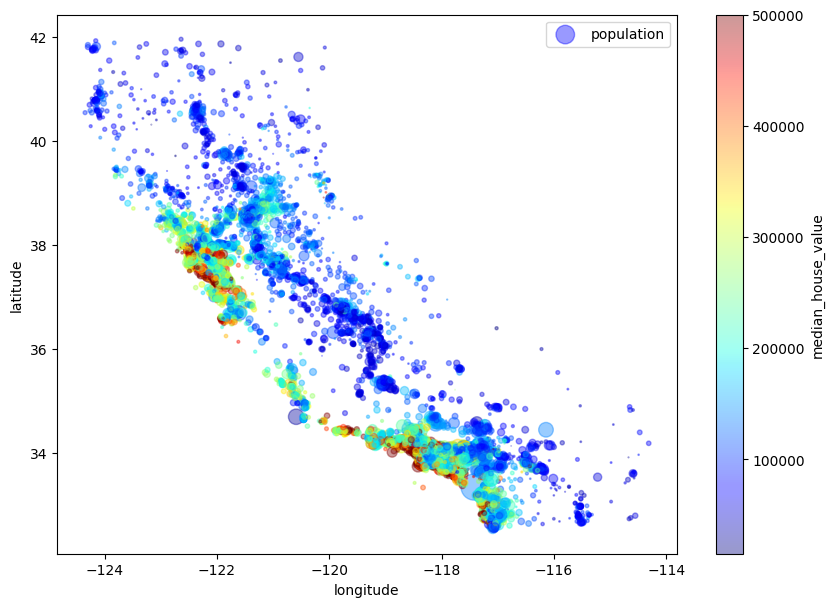

In [23]:
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
             s= housing["population"]/100, label="population", figsize=(10,7),
             c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True)
plt.legend()